In [5]:
import pandas as pd
from sklearn.cluster import KMeans

value_system_df = pd.read_csv('2026-02-10_UK_ess_value_system.csv', sep=',', na_values=[''], quotechar='"')
value_system_df

,country,P__Universalism__Universalism,P__Universalism__Benevolence,P__Universalism__Tradition,P__Universalism__Conformity,P__Universalism__Security,P__Universalism__Power,P__Universalism__Achievement,P__Universalism__Hedonism,P__Universalism__Stimulation,...,VA__Hedonism__lgbt_adopt,VA__Hedonism__lgbt_freedom,VA__Stimulation__brexit,VA__Stimulation__immigration,VA__Stimulation__lgbt_adopt,VA__Stimulation__lgbt_freedom,VA__Self-Direction__brexit,VA__Self-Direction__immigration,VA__Self-Direction__lgbt_adopt,VA__Self-Direction__lgbt_freedom
0,21,0.5,0.444444,1.944444e-01,0.277778,0.527778,0.111111,0.277778,0.277778,0.027778,...,-0.067901,-0.067901,-0.623457,0.623457,-0.623457,-0.623457,3.024691e-01,-3.024691e-01,3.024691e-01,3.024691e-01
1,23,0.5,0.416667,5.000000e-01,0.166667,0.500000,0.083333,0.416667,0.333333,0.000000,...,0.074074,0.074074,-0.666667,0.666667,-0.666667,-0.666667,-4.814815e-01,4.814815e-01,-4.814815e-01,-4.814815e-01
2,53,0.5,0.625000,5.000000e-01,0.625000,0.625000,0.125000,0.500000,0.250000,0.125000,...,-0.333333,-0.333333,-0.611111,0.611111,-0.611111,-0.611111,-6.111111e-01,6.111111e-01,-6.111111e-01,-6.111111e-01
3,82,0.5,0.500000,5.000000e-01,0.416667,0.250000,0.000000,0.083333,0.000000,0.000000,...,-0.277778,-0.277778,-0.277778,0.493827,-0.277778,-0.277778,1.233581e-17,-2.193033e-17,1.233581e-17,1.233581e-17
4,89,0.5,0.500000,7.000000e-01,0.400000,0.400000,0.300000,0.400000,0.800000,0.600000,...,0.300000,0.300000,0.077778,-0.155556,0.077778,0.077778,1.888889e-01,-3.777778e-01,1.888889e-01,1.888889e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1941,69664,0.5,0.562500,1.875000e-01,0.125000,0.375000,0.312500,0.375000,0.375000,0.500000,...,-0.041667,-0.041667,0.236111,-0.236111,0.236111,0.236111,5.138889e-01,-5.138889e-01,5.138889e-01,5.138889e-01
1942,69820,0.5,0.571429,7.142857e-01,0.714286,0.714286,0.214286,0.214286,0.642857,0.285714,...,0.134921,0.134921,-0.523810,0.232804,-0.261905,-0.261905,2.698413e-01,-1.199295e-01,1.349206e-01,1.349206e-01
1943,69885,0.5,0.555556,3.888889e-01,0.222222,0.222222,0.055556,0.055556,0.305556,0.222222,...,0.015432,0.030864,-0.077160,0.154321,-0.077160,-0.154321,1.080247e-01,-2.160494e-01,1.080247e-01,2.160494e-01
1944,69887,0.5,0.476190,4.761905e-02,0.404762,0.547619,0.261905,0.404762,0.476190,0.119048,...,-0.000000,0.140212,-0.513228,0.513228,0.000000,-0.256614,-1.957672e-01,1.957672e-01,0.000000e+00,-9.788360e-02


## Notes

- "Immigration" means "Immigration bad or good for country's economy", where a higher value means **good**.
- "lgbt_freedom" means "Gay men and lesbians should be free to live life as they wish", where a higher value means **yes**
- "lgbt_adopt" means "Gay men and lesbians should have the same rights to adopt children as straight couples", where a higher value means **yes**

- If no country is specified, plots are over **all** countries

## Step 1: Understand the relationship of action judgements
- An action judgement states: If the action is taken, then to what extent will my value be promoted or demoted? (In the opinion of the agent)

### Key Conclusions
- Polarising actions have very strong, differing promotion and demotion between agents. We can see that Immigration is the most polarising action.

- Over all agents, "Immigration" shows a medium-strength correlation between certain values and actions. There are more extreme views portrayed, showing an increased level of polarisation.
- For LGBT rights and adoption, there is no strong correlation between actions and values. There is no overall trend, and the actions are not very polarising.

In [6]:
# Find all columns that start with "P__"
pref_cols = pd.DataFrame(value_system_df.filter(regex="^P__"))
# Remove all cols that have the same two values (P__Universalism__Universalism, P__Benevolence__Benevolence, etc.)
for col in pref_cols.columns:
    col_split = col.split("__")
    if len(col_split) == 3 and col_split[1] == col_split[2]:
        pref_cols = pref_cols.drop(col, axis=1)
    else:
        # Not dropped, so drop the symmetrical col (P__A__B == P__B__A)
        symmetrical_col = "P__"+ col_split[2] + "__" + col_split[1]
        if col in pref_cols.columns:
            pref_cols = pref_cols.drop(columns=[symmetrical_col], axis=1)

In [7]:
stds = pref_cols.std()
stds = stds.sort_values(ascending=True)
print("Standard Deviations for each comparison: \n", stds)

Standard Deviations for each comparison: 
 P__Universalism__Benevolence       0.136953
P__Benevolence__Power              0.158687
P__Benevolence__Tradition          0.164421
P__Benevolence__Security           0.166395
P__Universalism__Self-Direction    0.167282
P__Benevolence__Self-Direction     0.170635
P__Universalism__Tradition         0.173212
P__Universalism__Power             0.176686
P__Power__Achievement              0.176981
P__Power__Self-Direction           0.179041
P__Universalism__Security          0.181333
P__Benevolence__Hedonism           0.183347
P__Benevolence__Achievement        0.184135
P__Benevolence__Conformity         0.185101
P__Security__Power                 0.185748
P__Tradition__Security             0.188746
P__Conformity__Security            0.189691
P__Stimulation__Self-Direction     0.190111
P__Tradition__Conformity           0.191446
P__Hedonism__Stimulation           0.191720
P__Benevolence__Stimulation        0.192171
P__Universalism__Conformity      

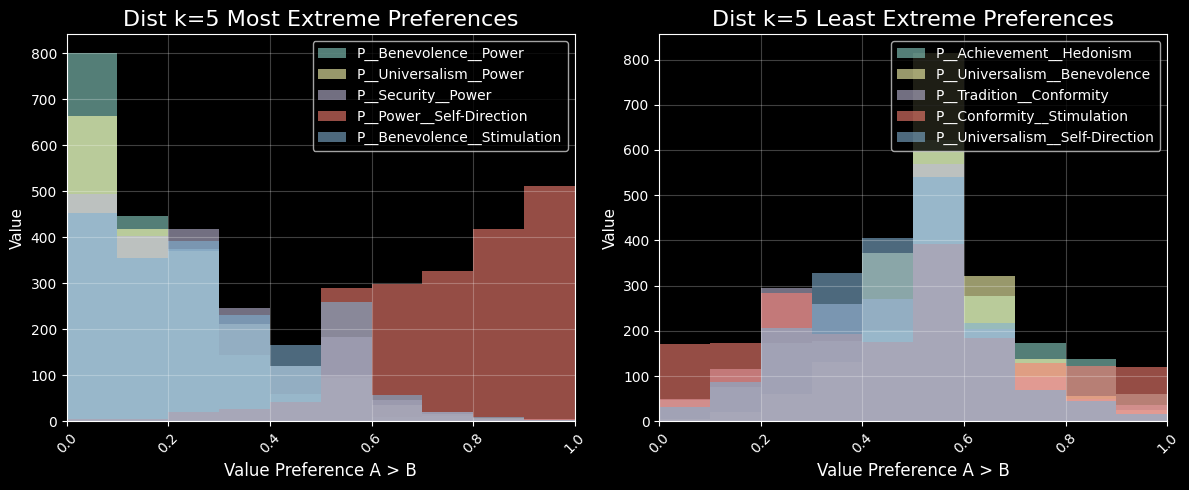

In [13]:
# There are 45 pairwise comparisons, look at top 10 for each (most nothing, most strong)
import matplotlib.pyplot as plt
k = 5
# Find cols that have a mean closest to 0 or 1, find the absolute difference to either 0 or 1 (depending on which side of 0.5 they're on), and then rank the distances
high_means = pref_cols.mean(axis=0).sort_values(ascending=False)
low_means = pref_cols.mean(axis=0).sort_values(ascending=True)
# Clip values
high_means = high_means.clip(lower=0.5, upper=1.0)
low_means = low_means.clip(lower=0.0, upper=0.5)
# Find diff
high_means = 1 - high_means
# Concat
means = pd.concat([high_means, low_means])
means = means.sort_values(ascending=True)

means_keys_high = means.keys().tolist()[:k]
#print("High keys: ", means_keys_high)
means = means.sort_values(ascending=False)
means_keys_low = means.keys().tolist()[:k]
#print("Low keys: ", means_keys_low)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1]})

for col in means_keys_high:
    pref_cols.hist(col, bins=10, alpha=0.6, label=col, ax=axes[0])
axes[0].set_title(f"Dist k={k} Most Extreme Preferences", fontsize=16)
axes[0].set_xlabel('Value Preference A > B', fontsize=12)
axes[0].set_ylabel('Frequency Amongst Agents', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_ylabel("Value", fontsize=11)
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=0.25)
axes[0].set_xlim(0, 1)

for col in means_keys_low:
    pref_cols.hist(col, bins=10, alpha=0.6, label=col, ax=axes[1])
axes[1].set_title(f"Dist k={k} Least Extreme Preferences", fontsize=16)
axes[1].set_xlabel('Value Preference A > B', fontsize=12)
axes[1].set_ylabel('Frequency Amongst Agents', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].set_ylabel("Value", fontsize=11)
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.25)
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


### Notes on Value Preferences
- What happens to the performance of value aggregators when we remove the "noise" of indifferent value preferences?
- Are the extreme value preferences reflected in our actions? Are more extreme opinions on the actions shared by agents with more extreme value preferences?

**Values in Extreme Preferences suggest:**
- *Strong preference for:* **Power**, Stimulation, Achievement
- *Strong Preference against:* Tradition, Self-Direction, Benevolence, Security, Stimulation, **Power**

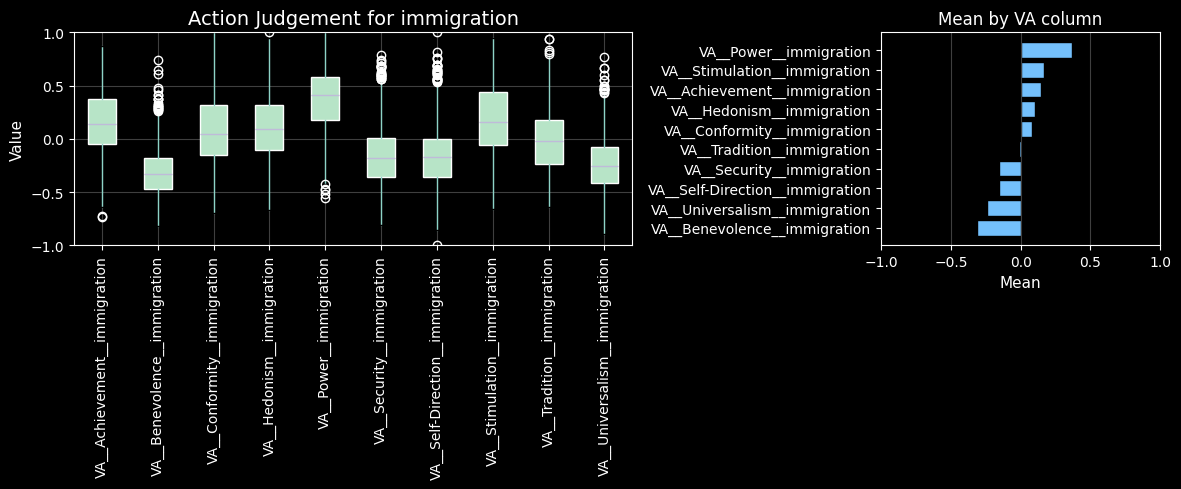

In [9]:
import re
import matplotlib.pyplot as plt

def _va_cols_for_topic(df, topic: str):
    # Get all VA columns for a given topic
    pattern = re.compile(rf"^VA__.*__{re.escape(topic)}$", flags=re.IGNORECASE)
    return [c for c in df.columns if pattern.match(c)]

def plot_va_topic(df, topic: str, figsize=(12, 5)):
    # Plot VA boxplot and mean by VA column for a given topic
    cols = _va_cols_for_topic(df, topic)
    if not cols:
        raise ValueError(f"No VA columns found for topic '{topic}'. Expected columns like 'VA__<Value>__{topic}'.")
    cols = sorted(cols)

    fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={"width_ratios": [2, 1]})

    df[cols].boxplot(ax=axes[0], patch_artist=True, boxprops=dict(facecolor="#b7e4c7"))
    axes[0].set_title(f"Action Judgement for {topic}", fontsize=14)
    axes[0].set_ylabel("Value", fontsize=11)
    axes[0].tick_params(axis="x", rotation=90)
    axes[0].set_ylim(-1, 1)
    axes[0].grid(alpha=0.25)

    means = df[cols].mean(numeric_only=True).sort_values(ascending=False)
    axes[1].barh(means.index, means.values, color="#74c0fc", edgecolor="black")
    axes[1].set_title("Mean by VA column", fontsize=12)
    axes[1].set_xlabel("Mean", fontsize=11)
    axes[1].invert_yaxis()
    axes[1].set_xlim(-1, 1)
    axes[1].grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

plot_va_topic(value_system_df, "immigration")

### Notes: Immigration is good for the economony Action
- Medium-Strength (+/- 0.5) matching Schwartz Values
    - Self-Direction, Stimulation, Power, Benevolence, Universalism

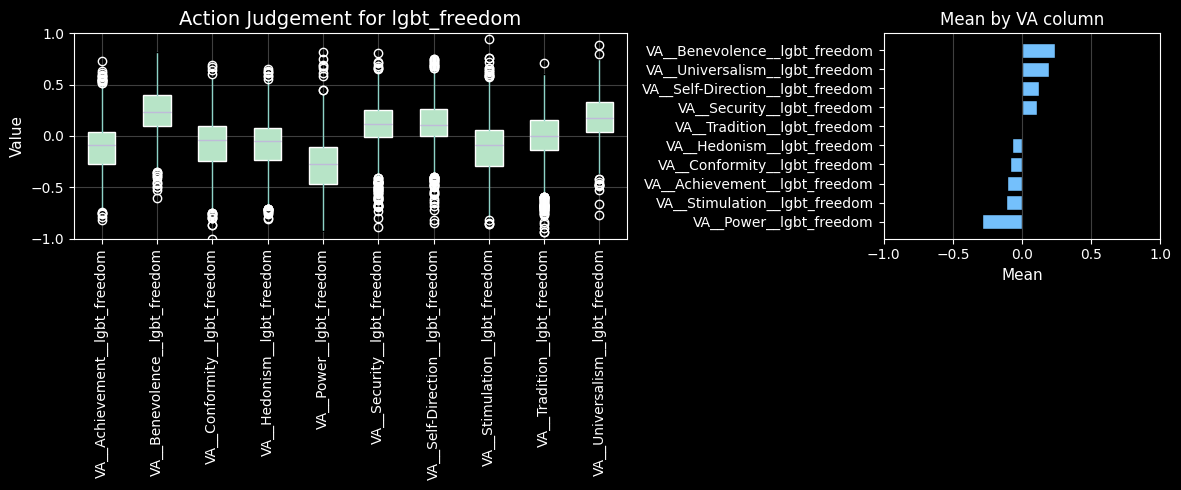

In [10]:
plot_va_topic(value_system_df, "lgbt_freedom")

### Notes: LGBT Rights Action
- Low-Strength correlation between values and actions, with a few agents having stronger correlations.
- No overall large trend.

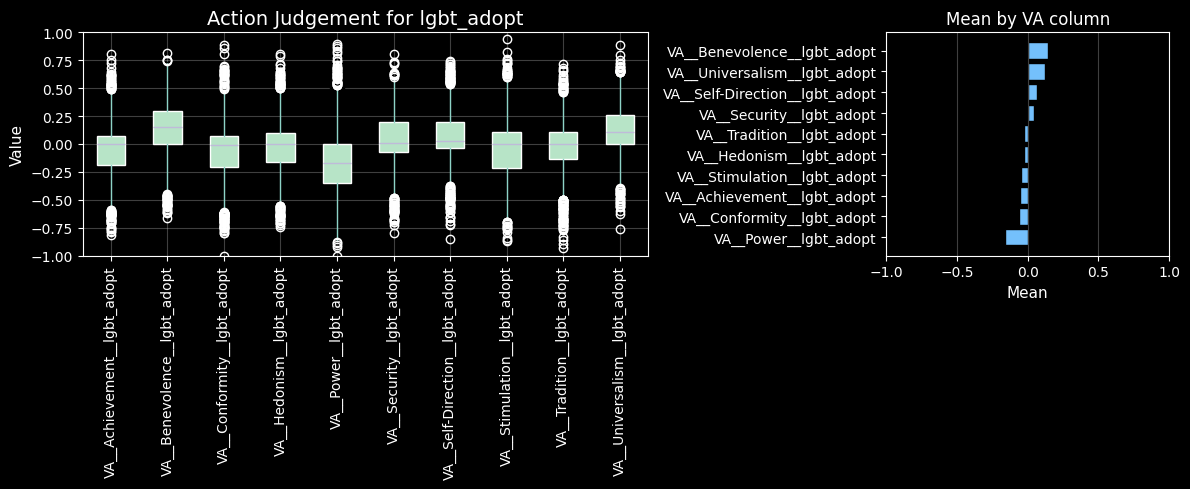

In [11]:
plot_va_topic(value_system_df, "lgbt_adopt")


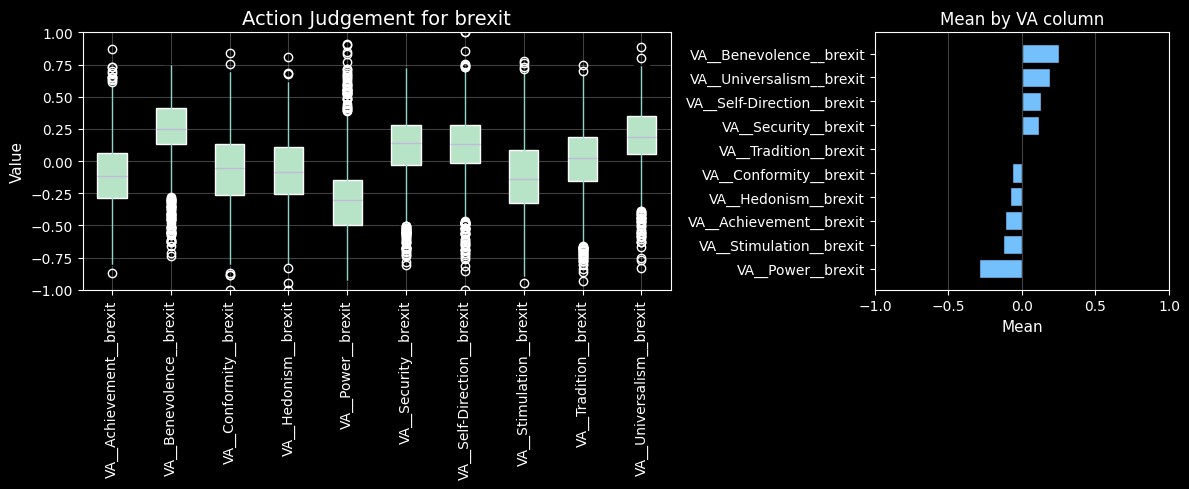

In [14]:
plot_va_topic(value_system_df, "brexit")

### Notes: LGBT Adoption Action
- Low-Strength correlation with no extreme positions within the entire group.

### K-Means clustering/PCA analysis to find clusters of agents with similar action judgements
- Here we are looking to find distinct clusters. An ideal scenario would be i) one large cluster, with a small opposing cluster ii) two strongly opposing clusters of similar size. iii) No clear clusters.

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _va_cols_for_action(df: pd.DataFrame, action: str):
    suffix = f"__{action}"
    return [c for c in df.columns if c.startswith("VA__") and c.endswith(suffix)]

def PCA_per_action(df, actions=("brexit", "immigration", "lgbt_adopt", "lgbt_freedom")):
    for action in actions:
        cols = sorted(_va_cols_for_action(df, action))
        print(f"PCA for {action}: {cols}")
        scaler = StandardScaler()
        # take col data, and scale between 0-1, std 1, for PCA
        X = df[cols].to_numpy(dtype=float)
        print(X.shape)
        X = scaler.fit_transform(X)
        print(X.shape)
        pca_output = PCA(n_components=2).fit_transform(X)
        print(pca_output.shape)

        plt.figure(figsize=(6.5, 5.2))
        plt.scatter(pca_output[:, 0], pca_output[:, 1], s=55, alpha=0.85, edgecolor="white", linewidth=0.5, label=action)
        plt.title(f"PCA view of {action} action judgements")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.xlim(-4, 4)
        plt.ylim(-4, 4)
        plt.grid(alpha=0.25)
        plt.legend(frameon=True)

PCA_per_action(value_system_df)

PCA for brexit: ['VA__Achievement__brexit', 'VA__Benevolence__brexit', 'VA__Conformity__brexit', 'VA__Hedonism__brexit', 'VA__Power__brexit', 'VA__Security__brexit', 'VA__Self-Direction__brexit', 'VA__Stimulation__brexit', 'VA__Tradition__brexit', 'VA__Universalism__brexit']
(1946, 10)
(1946, 10)


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [15]:
## K Means Clustering per action
import seaborn as sns

def k_means_actions(df, actions=("immigration", "lgbt_adopt", "lgbt_freedom")):
    for action in actions:
        cols = _va_cols_for_action(df, action)
        X = df[cols].to_numpy(dtype=float)
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
        kmeans = KMeans(n_clusters=2, random_state=0).fit_predict(X)
        ## Have two plots, one showing the clusters, another showing the decisions made by each cluster
        ## Decision is calculated as the sum of each value judgement multiplied by the associated preference for a value

        plt.figure(figsize=(6.5, 5.2))
        plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="tab10", s=55, alpha=0.85, edgecolor="white", linewidth=0.5, label=action)
        plt.title(f"K-Means clustering of {action} action judgements")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.xlim(-4,4)
        plt.ylim(-4, 4)


        sns.boxplot(x= means.labels_)

k_means_actions(value_system_df)


ModuleNotFoundError: No module named 'seaborn'

### Step 3: Connection between principles and personal values

### Step 4: Correlation with real support/disagreement and decision made by an agent's PVS